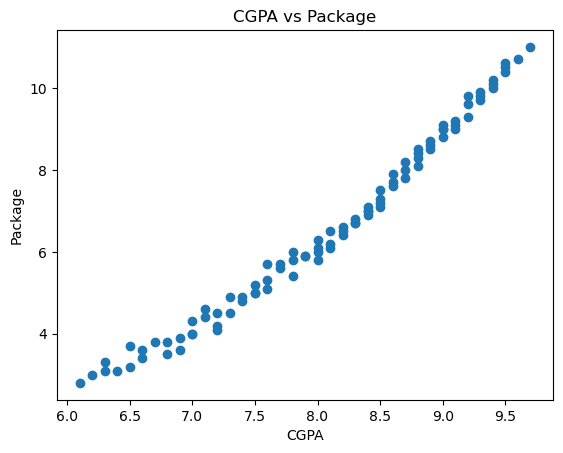

Coefficient:  [1.53152658 0.2791608  0.49759255]
Intercept:  -7.368730395761633
Mean Absolute Error:  0.22384697075068982
Mean Squared Error:  0.08818718944606659
R^2 Score:  0.9840467961925324
                 CGPA  Projects  Internships
CGPA         1.000000  0.918941     0.879677
Projects     0.918941  1.000000     0.732477
Internships  0.879677  0.732477     1.000000
[0.97261279 0.98571748 0.98512495 0.98340843 0.97628583]
    CGPA  Projects  Internships  Actual Package  Predicted Package
36   8.7         4            2             8.0           8.067379
28   7.1         2            1             4.6           4.561023
54   9.3         5            3             9.9           9.763049
23   9.4         5            3            10.1           9.916201
16   8.7         3            2             7.8           7.788218


CGPA:  9
No. of  Projects:  5
No. of Internships:  3


Predicted Placement Package:  9.3  LPA 


In [20]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score
placement=pd.read_csv("Placement.csv")
x=placement[["CGPA","Projects","Internships"]]
y=placement["Package_LPA"]
xtrain,xtest,ytrain,ytest=train_test_split(x,y,test_size=0.2,random_state=2)
model=LinearRegression()
model.fit(xtrain,ytrain)
ypredict=model.predict(xtest)
plt.scatter(placement["CGPA"],y)
plt.xlabel("CGPA")
plt.ylabel("Package")
plt.title("CGPA vs Package")
plt.show()
print("Coefficient: ",model.coef_)
print("Intercept: ",model.intercept_)
print("Mean Absolute Error: ",mean_absolute_error(ytest,ypredict))
print("Mean Squared Error: ",mean_squared_error(ytest,ypredict))
print("R^2 Score: ",r2_score(ytest,ypredict))
print(placement[["CGPA","Projects","Internships"]].corr())
print(cross_val_score(LinearRegression(), x, y, cv=5, scoring="r2"))
df=pd.DataFrame({'CGPA':xtest["CGPA"],'Projects':xtest['Projects'],'Internships':xtest['Internships'],'Actual Package':ytest,'Predicted Package':ypredict})
print(df.head())
cgpa=float(input("CGPA: "))
project=float(input("No. of  Projects: "))
internship=float(input("No. of Internships: "))

features=pd.DataFrame({'CGPA':[cgpa],'Projects':[project],'Internships':[internship]})
prediction=model.predict(features)
print("Predicted Placement Package: ",prediction[0].round(2)," LPA ")